In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
figures_dir = repo_root / "figures"
reports_dir = repo_root / "reports"

figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

In [4]:
data_path = repo_root / "data" / "processed" / "alsfrs_modeling_week5.csv"
df = pd.read_csv(data_path)

print(df.shape)
df.head()

(45841, 12)


,subject_id,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset,alsfrs_r_total
0,3301,40.0,2,35.0,35.0,35.0,35.0,NaN,Male,-1049.0,Onset: Limb,34.0
1,3301,98.0,3,35.0,34.0,93.0,58.0,NaN,Male,-1049.0,Onset: Limb,32.0
2,3301,161.0,4,35.0,32.0,156.0,63.0,NaN,Male,-1049.0,Onset: Limb,32.0
3,3301,221.0,5,35.0,32.0,216.0,60.0,NaN,Male,-1049.0,Onset: Limb,34.0
4,3301,273.0,6,35.0,34.0,268.0,52.0,NaN,Male,-1049.0,Onset: Limb,32.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45841 entries, 0 to 45840
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subject_id               45841 non-null  int64  
 1   alsfrs_delta             45841 non-null  float64
 2   visit_number             45841 non-null  int64  
 3   baseline_alsfrs_r_total  45841 non-null  float64
 4   prev_alsfrs_r_total      45841 non-null  float64
 5   time_since_first_visit   45841 non-null  float64
 6   delta_from_prev_visit    45841 non-null  float64
 7   age                      40257 non-null  float64
 8   sex                      45841 non-null  object 
 9   onset_delta              44291 non-null  float64
 10  site_of_onset            30865 non-null  object 
 11  alsfrs_r_total           45841 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 4.2+ MB


In [6]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary.head(15)

,missing_count,missing_percent
site_of_onset,14976,32.669444
age,5584,12.181235
onset_delta,1550,3.381253
subject_id,0,0.000000
alsfrs_delta,0,0.000000
visit_number,0,0.000000
baseline_alsfrs_r_total,0,0.000000
prev_alsfrs_r_total,0,0.000000
time_since_first_visit,0,0.000000
delta_from_prev_visit,0,0.000000


In [8]:
target_col = "alsfrs_r_total"
drop_cols = [target_col]

possible_id_cols = ["subject_id", "visit_id"]

for col in possible_id_cols:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (45841, 10)
y shape: (45841,)


,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset
0,40.0,2,35.0,35.0,35.0,35.0,NaN,Male,-1049.0,Onset: Limb
1,98.0,3,35.0,34.0,93.0,58.0,NaN,Male,-1049.0,Onset: Limb
2,161.0,4,35.0,32.0,156.0,63.0,NaN,Male,-1049.0,Onset: Limb
3,221.0,5,35.0,32.0,216.0,60.0,NaN,Male,-1049.0,Onset: Limb
4,273.0,6,35.0,34.0,268.0,52.0,NaN,Male,-1049.0,Onset: Limb


In [9]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 8
Categorical features: 2


In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(36672, 10) (9169, 10) (36672,) (9169,)


In [13]:
models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [14]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    
    return pipeline, preds, mae, rmse, r2

In [15]:
results = []
fitted_pipelines = {}
test_predictions = {}

for name, model in models.items():
    pipeline, preds, mae, rmse, r2 = evaluate_regression_model(
        model, X_train, X_test, y_train, y_test
    )
    
    fitted_pipelines[name] = pipeline
    test_predictions[name] = preds
    
    results.append({
        "model": name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="rmse")
results_df

,model,mae,rmse,r2
2,gradient_boosting,1.810437,2.558294,0.916010
0,linear_regression,1.832540,2.593635,0.913673
1,random_forest,1.902107,2.685880,0.907424


In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )
    
    cv_results.append({
        "model": name,
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_rmse_mean")
cv_results_df

,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
2,gradient_boosting,1.804572,0.025022,2.576774,0.043033,0.913865,0.003339
0,linear_regression,1.829522,0.027321,2.617424,0.048628,0.911117,0.003798
1,random_forest,1.880091,0.021686,2.669757,0.035622,0.907554,0.002806


In [17]:
robustness_summary = results_df.merge(cv_results_df, on="model", how="left")
robustness_summary

,model,mae,rmse,r2,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,gradient_boosting,1.810437,2.558294,0.916010,1.804572,0.025022,2.576774,0.043033,0.913865,0.003339
1,linear_regression,1.832540,2.593635,0.913673,1.829522,0.027321,2.617424,0.048628,0.911117,0.003798
2,random_forest,1.902107,2.685880,0.907424,1.880091,0.021686,2.669757,0.035622,0.907554,0.002806


In [18]:
best_model_name = robustness_summary.sort_values(by="rmse").iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = test_predictions[best_model_name]

print("Best model:", best_model_name)

Best model: gradient_boosting


In [19]:
residual_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": best_preds,
    "residual": y_test.values - best_preds
})

residual_df.head()

,actual,predicted,residual
0,30.0,28.029361,1.970639
1,30.0,28.280098,1.719902
2,31.0,30.440395,0.559605
3,37.0,37.649248,-0.649248
4,18.0,21.207475,-3.207475


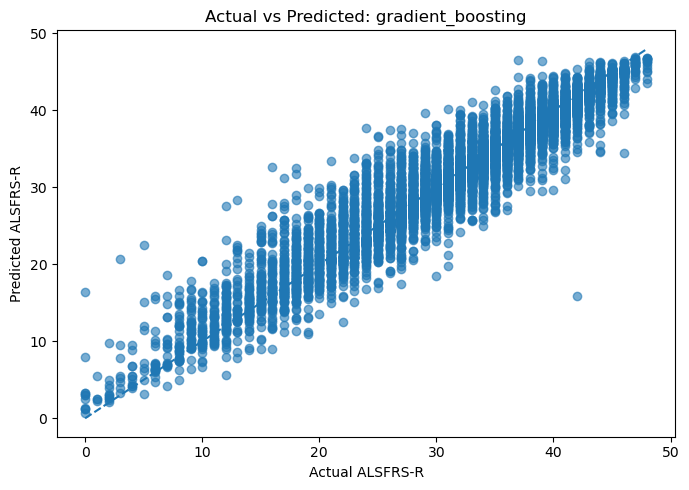

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(residual_df["actual"], residual_df["predicted"], alpha=0.6)
plt.plot(
    [residual_df["actual"].min(), residual_df["actual"].max()],
    [residual_df["actual"].min(), residual_df["actual"].max()],
    linestyle="--"
)
plt.xlabel("Actual ALSFRS-R")
plt.ylabel("Predicted ALSFRS-R")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.tight_layout()
plt.savefig(figures_dir / "week8_rf_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

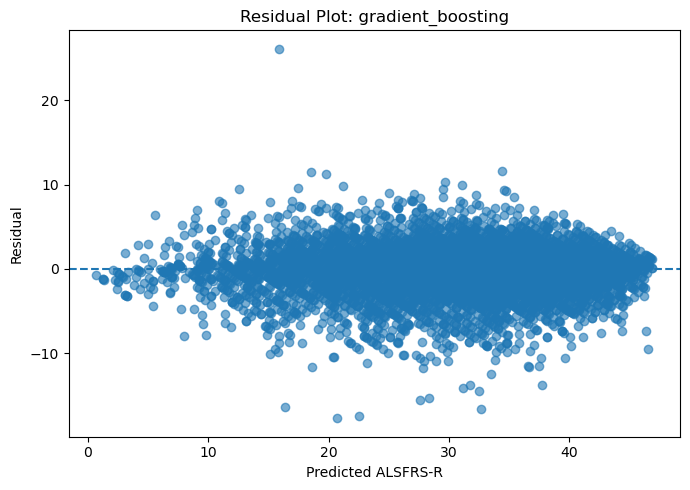

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(residual_df["predicted"], residual_df["residual"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted ALSFRS-R")
plt.ylabel("Residual")
plt.title(f"Residual Plot: {best_model_name}")
plt.tight_layout()
plt.savefig(figures_dir / "week8_rf_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

feature_names = []

if numeric_features:
    feature_names.extend(numeric_features)

if categorical_features:
    ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    encoded_cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(encoded_cat_names)

print("Total transformed features:", len(feature_names))

Total transformed features: 15


In [23]:
best_estimator = best_pipeline.named_steps["model"]

if best_model_name == "random_forest":
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": best_estimator.feature_importances_
    }).sort_values(by="importance", ascending=False)
    
    importances.head(15)
else:
    importances = None
    print("Built-in feature importance is only available here for random forest.")

Built-in feature importance is only available here for random forest.


In [24]:
if importances is not None:
    top_importances = importances.head(15).sort_values(by="importance")
    
    plt.figure(figsize=(8, 6))
    plt.barh(top_importances["feature"], top_importances["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top Random Forest Feature Importances")
    plt.tight_layout()
    plt.savefig(figures_dir / "week8_rf_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

In [25]:
perm_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

permutation_df.head(15)

,feature,importance_mean,importance_std
3,prev_alsfrs_r_total,1.635727,0.017378
2,baseline_alsfrs_r_total,0.023124,0.001322
5,delta_from_prev_visit,0.019538,0.000553
8,onset_delta,0.003344,0.000350
1,visit_number,0.001365,0.000126
4,time_since_first_visit,0.001084,0.000094
0,alsfrs_delta,0.000413,0.000084
6,age,0.000217,0.000065
7,sex,0.000018,0.000018
9,site_of_onset,-0.000046,0.000058


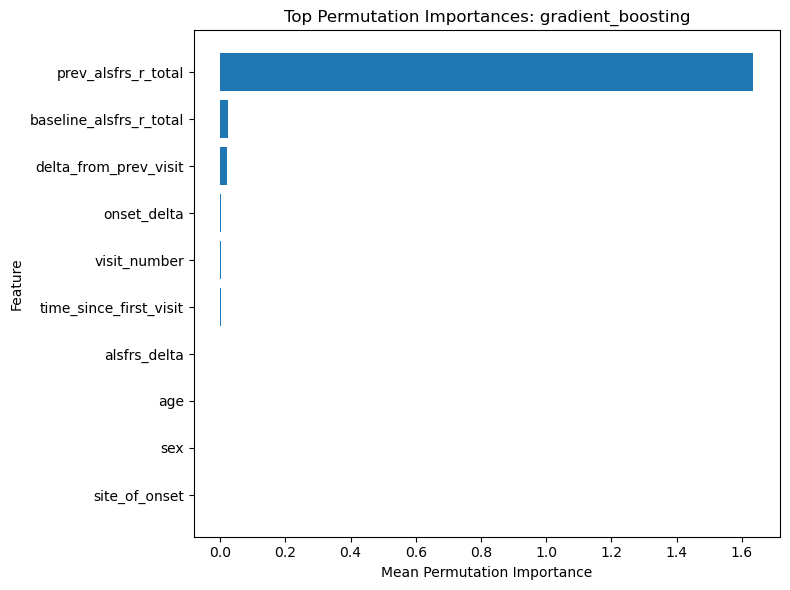

In [26]:
top_perm = permutation_df.head(15).sort_values(by="importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.title(f"Top Permutation Importances: {best_model_name}")
plt.tight_layout()
plt.savefig(figures_dir / "week8_rf_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
X_test_with_meta = X_test.copy()
X_test_with_meta["actual"] = y_test.values
X_test_with_meta["predicted"] = best_preds
X_test_with_meta["absolute_error"] = (X_test_with_meta["actual"] - X_test_with_meta["predicted"]).abs()

In [28]:
subgroup_results = []

if "sex" in X_test_with_meta.columns:
    sex_summary = (
        X_test_with_meta.groupby("sex")["absolute_error"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )
    sex_summary["subgroup_type"] = "sex"
    sex_summary = sex_summary.rename(columns={"sex": "subgroup_value"})
    subgroup_results.append(sex_summary)

sex_summary if "sex" in X_test_with_meta.columns else "sex column not available"

,subgroup_value,count,mean,median,subgroup_type
0,Female,3315,1.871604,1.280498,sex
1,Male,5854,1.775800,1.233383,sex


In [29]:
if "age" in X_test_with_meta.columns:
    X_test_with_meta["age_group"] = pd.cut(
        X_test_with_meta["age"],
        bins=[0, 50, 60, 70, 120],
        labels=["<=50", "51-60", "61-70", "71+"]
    )
    
    age_summary = (
        X_test_with_meta.groupby("age_group")["absolute_error"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )
    age_summary["subgroup_type"] = "age_group"
    age_summary = age_summary.rename(columns={"age_group": "subgroup_value"})
    subgroup_results.append(age_summary)

age_summary if "age" in X_test_with_meta.columns else "age column not available"

,subgroup_value,count,mean,median,subgroup_type
0,<=50,2304,1.765871,1.209707,age_group
1,51-60,2565,1.692374,1.132329,age_group
2,61-70,2275,1.775840,1.241564,age_group
3,71+,864,1.847386,1.255386,age_group


In [30]:
if subgroup_results:
    subgroup_error_summary = pd.concat(subgroup_results, ignore_index=True)
else:
    subgroup_error_summary = pd.DataFrame()

subgroup_error_summary

,subgroup_value,count,mean,median,subgroup_type
0,Female,3315,1.871604,1.280498,sex
1,Male,5854,1.775800,1.233383,sex
2,<=50,2304,1.765871,1.209707,age_group
3,51-60,2565,1.692374,1.132329,age_group
4,61-70,2275,1.775840,1.241564,age_group
5,71+,864,1.847386,1.255386,age_group


In [32]:
robustness_summary.to_csv(
    reports_dir / "week8_model_robustness_summary.csv",
    index=False
)

if subgroup_error_summary.shape[0] > 0:
    subgroup_error_summary.to_csv(
        reports_dir / "week8_subgroup_error_summary.csv",
        index=False
    )

if importances is not None:
    importances.to_csv(
        reports_dir / "week8_rf_feature_importance.csv",
        index=False
    )

permutation_df.to_csv(
    reports_dir / "week8_permutation_importance.csv",
    index=False
)